# Prueba de acceso a datos con Google Earth Engine (Python, Colab)

Notebook de prueba para evaluar el flujo con GEE en el environment `1geo20`.

1. Autenticación y conexión
2. Producto de cobertura (ESA WorldCover) sobre una área dada
3. Sentinel-2 SR y cálculo de NDVI
4. Integración, en local y en el servidor



## Bloque 1. Conexión

In [1]:
!pip install -q rioxarray

In [2]:
import ee
import requests
import numpy as np
import matplotlib.pyplot as plt
import rioxarray
from rasterio.enums import Resampling

In [3]:
# 1. Autenticación
ee.Authenticate(auth_mode='notebook')

True

In [4]:
PROJECT_ID = 'vmt-waaa'   # reemplazar por el Project ID
ee.Initialize(project=PROJECT_ID)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [5]:
# lon_min, lat_min, lon_max, lat_max
BBOX = [-69.30, -12.70, -69.10, -12.50]
region = ee.Geometry.Rectangle(BBOX)

print("Conexión exitosa:", ee.String("Google Earth Engine activo").getInfo())

Conexión exitosa: Google Earth Engine activo


## Bloque 2. ESA WorldCover

In [6]:
def descargar(img, nombre, escala):
    """Descarga el recorte de una imagen de GEE como GeoTIFF y lo abre con rioxarray."""
    url = img.getDownloadURL({
        "region": region,
        "scale": escala,
        "crs": "EPSG:4326",
        "format": "GEO_TIFF",
    })
    r = requests.get(url, timeout=300)
    r.raise_for_status()
    with open(nombre, "wb") as f:
        f.write(r.content)
    print(nombre, f"{len(r.content) / 1e6:.1f} MB")
    return rioxarray.open_rasterio(nombre).squeeze("band", drop=True)

In [7]:
%%time
wc_img = ee.ImageCollection("ESA/WorldCover/v200").first().select("Map")
wc = descargar(wc_img, "worldcover_gee.tif", 10)
print(wc.rio.crs, wc.rio.resolution(), wc.shape)

worldcover_gee.tif 0.2 MB
EPSG:4326 (8.983152841195215e-05, -8.983152841195215e-05) (2227, 2228)
CPU times: total: 141 ms
Wall time: 2.8 s


 10  Árboles               75.8 %
 20  Arbustos               0.1 %
 30  Pastizal              14.5 %
 40  Cultivos               0.2 %
 50  Urbano                 2.9 %
 60  Suelo desnudo/ralo     0.2 %
 80  Agua                   6.1 %
 90  Humedal herbáceo       0.3 %


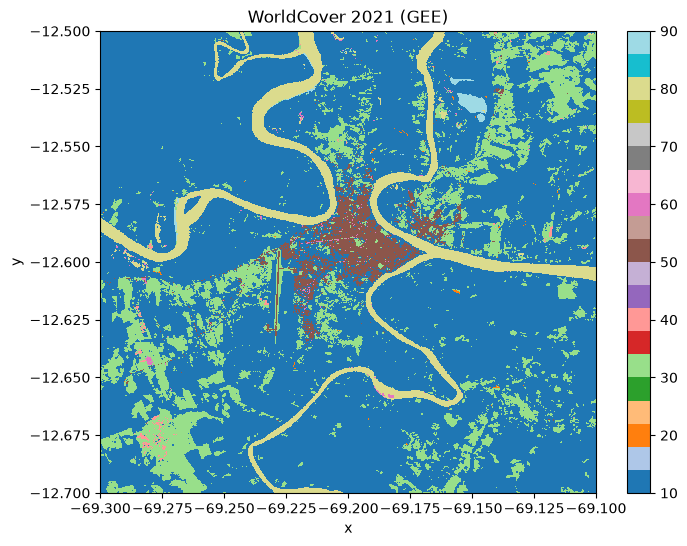

In [8]:
CLASES = {
    10: "Árboles", 20: "Arbustos", 30: "Pastizal", 40: "Cultivos", 50: "Urbano",
    60: "Suelo desnudo/ralo", 70: "Nieve/hielo", 80: "Agua", 90: "Humedal herbáceo",
    95: "Manglar", 100: "Musgo/líquenes",
}

codigos, cuentas = np.unique(wc.values, return_counts=True)
for cod, k in zip(codigos, cuentas):
    print(f"{cod:>3}  {CLASES.get(int(cod), '?'):<20} {100 * k / cuentas.sum():5.1f} %")

wc.plot(cmap="tab20", figsize=(8, 6))
plt.title("WorldCover 2021 (GEE)")
plt.show()

## Bloque 3. Sentinel-2 SR y NDVI

In [9]:
coleccion = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(region)
    .filterDate("2025-07-01", "2025-09-30")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .filter(ee.Filter.contains(leftField=".geo", rightValue=region))
)
n = coleccion.size().getInfo()
assert n > 0, "Ninguna escena cubre el área completo; amplía las fechas o el umbral de nubes"
print(n, "escenas")

escena = coleccion.sort("CLOUDY_PIXEL_PERCENTAGE").first()
print(escena.get("system:index").getInfo(), escena.get("CLOUDY_PIXEL_PERCENTAGE").getInfo(), "% nubes")

15 escenas
20250830T144751_20250830T145441_T19LDG 0.004375 % nubes


In [10]:
%%time
# La colección HARMONIZED ya compensa el offset de la línea base 04.00
ndvi_img = escena.normalizedDifference(["B8", "B4"]).rename("NDVI")
ndvi = descargar(ndvi_img, "ndvi_gee.tif", 10)
print(ndvi.shape, float(ndvi.min()), float(ndvi.max()))

ndvi_gee.tif 16.3 MB
(2227, 2228) -0.49635037779808044 0.9255985021591187
CPU times: total: 344 ms
Wall time: 8.43 s


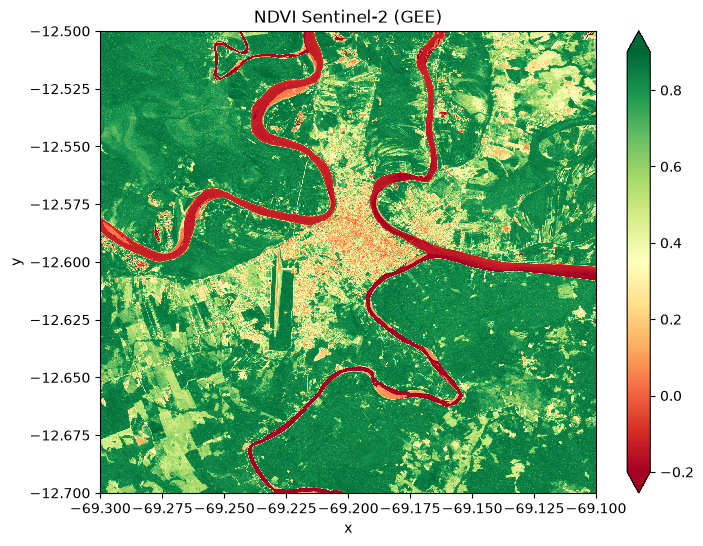

In [11]:
ndvi.plot(cmap="RdYlGn", vmin=-0.2, vmax=0.9, figsize=(8, 6))
plt.title("NDVI Sentinel-2 (GEE)")
plt.show()

ndvi_compuesto_gee.tif 16.2 MB


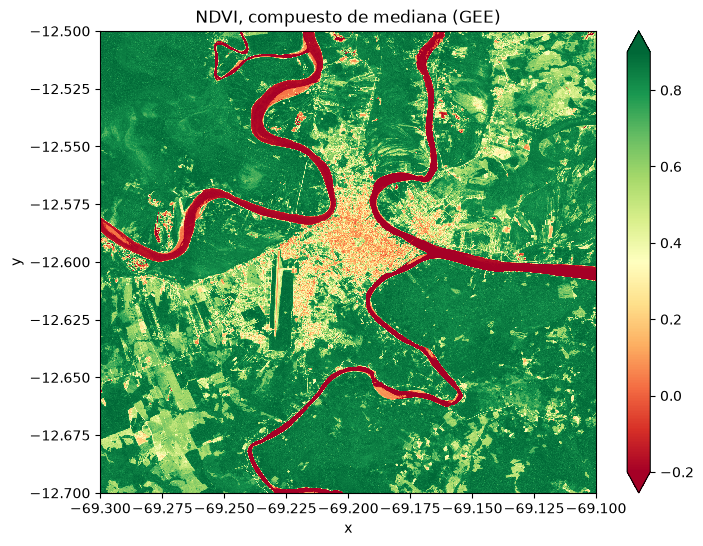

CPU times: total: 3.23 s
Wall time: 20.7 s


In [12]:
%%time
# Opcional. Compuesto de mediana de todas las escenas filtradas, sin elegir una sola escena
ndvi_comp_img = coleccion.median().normalizedDifference(["B8", "B4"]).rename("NDVI")
ndvi_comp = descargar(ndvi_comp_img, "ndvi_compuesto_gee.tif", 10)

ndvi_comp.plot(cmap="RdYlGn", vmin=-0.2, vmax=0.9, figsize=(8, 6))
plt.title("NDVI, compuesto de mediana (GEE)")
plt.show()

## Bloque 4. Integración

In [13]:
# Opción local. Misma lógica que en el notebook de STAC
wc_alineado = wc.rio.reproject_match(ndvi, resampling=Resampling.nearest)
wc_alineado = wc_alineado.where(wc_alineado.isin(list(CLASES)))

por_clase = ndvi.groupby(wc_alineado.rename("clase")).mean()
for cod, v in zip(por_clase["clase"].values, por_clase.values):
    print(f"{CLASES[int(cod)]:<20} NDVI medio {v:5.2f}")

Árboles              NDVI medio  0.77
Arbustos             NDVI medio  0.69
Pastizal             NDVI medio  0.55
Cultivos             NDVI medio  0.61
Urbano               NDVI medio  0.25
Suelo desnudo/ralo   NDVI medio  0.22
Agua                 NDVI medio -0.09
Humedal herbáceo     NDVI medio  0.59


In [14]:
%%time
# Opción en el servidor. Solo viajan los resultados, no los píxeles
stats = (
    ndvi_img.addBands(wc_img)
    .reduceRegion(
        reducer=ee.Reducer.mean().group(groupField=1, groupName="clase"),
        geometry=region,
        scale=10,
        maxPixels=1e9,
    )
    .getInfo()
)
for g in stats["groups"]:
    print(f"{CLASES[int(g['clase'])]:<20} NDVI medio {g['mean']:5.2f}")

Árboles              NDVI medio  0.77
Arbustos             NDVI medio  0.69
Pastizal             NDVI medio  0.55
Cultivos             NDVI medio  0.61
Urbano               NDVI medio  0.25
Suelo desnudo/ralo   NDVI medio  0.22
Agua                 NDVI medio -0.09
Humedal herbáceo     NDVI medio  0.58
CPU times: total: 78.1 ms
Wall time: 1.04 s
